# Final Group Model Comparison and Recommendation Demonstration

**Project:** Emotion-Aware Movie Recommendation System  
**Task:** Seven-class emotion classification and emotion-aware movie recommendation  
**Random state:** 42  

This notebook combines the genuine outputs produced by all six individual notebooks. It does not manually enter or invent model scores. The final classifier is selected using held-out macro F1, with accuracy, weighted F1, cross-validation performance, class-level behavior, and overfitting considered as supporting evidence.

## 1. Imports and repository paths

In [1]:
from pathlib import Path
import json
import shutil

import cloudpickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").exists():
    raise FileNotFoundError(
        "Could not locate the repository root containing data/."
    )

DATA_PATH = (
    PROJECT_ROOT
    / "data/processed/modelling_dataset_7class.csv"
)
RESULT_DIR = PROJECT_ROOT / "final_group_results"
FIGURE_DIR = RESULT_DIR / "visualizations"
OUTPUT_DIR = RESULT_DIR / "outputs"
MODEL_DIR = PROJECT_ROOT / "models"

for directory in [RESULT_DIR, FIGURE_DIR, OUTPUT_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Repository root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)

Repository root: /Users/lakshithadilshan/Documents/movie-emotion-recommendation-system
Dataset: /Users/lakshithadilshan/Documents/movie-emotion-recommendation-system/data/processed/modelling_dataset_7class.csv


## 2. Load the common seven-class dataset

All six models used the same 2,057-description dataset, stratified split, and random state. The `surprise` class remains available in the full EDA dataset but was excluded from supervised modelling because it contains only three independent descriptions.

In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print(
    "Duplicate descriptions:",
    int(df["Description"].duplicated().sum()),
)
display(df["emotion"].value_counts().to_frame("count"))

Dataset shape: (2057, 20)
Missing values: 0
Duplicate descriptions: 0


,count
emotion,
sadness,817
joy,400
anticipation,249
optimism,237
fear,150
anger,131
disgust,73


## 3. Collect the six individual results

Each metrics file was produced by an independently executed member notebook. The group comparison reads those files directly to preserve reproducibility and transparency.

In [3]:
model_sources = [
    {
        "student_id": "IT25100112",
        "student_name": "Karunarathne H. L. N. A.",
        "model": "Logistic Regression",
        "metrics": "IT25100112/results/outputs/logistic_regression_metrics.csv",
        "summary": "IT25100112/results/outputs/logistic_regression_summary.json",
        "saved_model": "IT25100112/results/outputs/IT25100112_best_logistic_regression.pkl",
    },
    {
        "student_id": "IT25100083",
        "student_name": "Unawatuna H. M. I. D.",
        "model": "Linear SVM",
        "metrics": "IT25100083/results/outputs/linear_svm_metrics.csv",
        "summary": "IT25100083/results/outputs/linear_svm_summary.json",
        "saved_model": "IT25100083/results/outputs/IT25100083_best_linear_svm.pkl",
    },
    {
        "student_id": "IT25100078",
        "student_name": "Thujikoshan Y.",
        "model": "Multinomial Naive Bayes",
        "metrics": "IT25100078/results/outputs/naive_bayes_metrics.csv",
        "summary": "IT25100078/results/outputs/naive_bayes_summary.json",
        "saved_model": "IT25100078/results/outputs/IT25100078_best_naive_bayes.pkl",
    },
    {
        "student_id": "IT25100090",
        "student_name": "Hettiarachchi H. C. N. G.",
        "model": "Decision Tree",
        "metrics": "IT25100090/results/outputs/decision_tree_metrics.csv",
        "summary": "IT25100090/results/outputs/decision_tree_summary.json",
        "saved_model": "IT25100090/results/outputs/IT25100090_best_decision_tree.pkl",
    },
    {
        "student_id": "IT25100111",
        "student_name": "Chandrasekara C. M. T. D.",
        "model": "Random Forest",
        "metrics": "IT25100111/results/outputs/random_forest_metrics.csv",
        "summary": "IT25100111/results/outputs/random_forest_summary.json",
        "saved_model": "IT25100111/results/outputs/IT25100111_best_random_forest.pkl",
    },
    {
        "student_id": "IT25100149",
        "student_name": "Rajapaksha P. A. D. S.",
        "model": "Multi-Layer Perceptron",
        "metrics": "IT25100149/results/outputs/mlp_metrics.csv",
        "summary": "IT25100149/results/outputs/mlp_summary.json",
        "saved_model": "IT25100149/results/outputs/IT25100149_best_mlp.pkl",
    },
]

comparison_rows = []
for source in model_sources:
    metrics_path = PROJECT_ROOT / source["metrics"]
    summary_path = PROJECT_ROOT / source["summary"]
    model_path = PROJECT_ROOT / source["saved_model"]

    for required_path in [metrics_path, summary_path, model_path]:
        if not required_path.exists():
            raise FileNotFoundError(
                f"Required individual result not found: {required_path}"
            )

    metrics = pd.read_csv(metrics_path, index_col=0)["score"]
    with open(summary_path, encoding="utf-8") as file:
        summary = json.load(file)

    comparison_rows.append({
        "student_id": source["student_id"],
        "student_name": source["student_name"],
        "model": source["model"],
        "train_accuracy": metrics.get("train_accuracy", np.nan),
        "test_accuracy": metrics.get("test_accuracy", np.nan),
        "accuracy_gap": metrics.get(
            "train_test_accuracy_gap",
            metrics.get("train_accuracy", np.nan)
            - metrics.get("test_accuracy", np.nan),
        ),
        "macro_precision": metrics.get("macro_precision", np.nan),
        "macro_recall": metrics.get("macro_recall", np.nan),
        "macro_f1": metrics.get("macro_f1", np.nan),
        "weighted_f1": metrics.get("weighted_f1", np.nan),
        "cv_macro_f1": metrics.get("best_cv_macro_f1", np.nan),
        "best_parameters": json.dumps(
            summary["best_parameters"],
            sort_keys=True,
        ),
        "saved_model": str(model_path),
    })

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values(
        ["macro_f1", "test_accuracy"],
        ascending=False,
    )
    .reset_index(drop=True)
)
comparison_df.insert(0, "rank", range(1, len(comparison_df) + 1))

display(
    comparison_df.drop(columns=["saved_model", "best_parameters"])
    .round(4)
)
comparison_df.to_csv(
    OUTPUT_DIR / "final_six_model_comparison.csv",
    index=False,
)

,rank,student_id,student_name,model,train_accuracy,test_accuracy,accuracy_gap,macro_precision,macro_recall,macro_f1,weighted_f1,cv_macro_f1
0,1,IT25100083,Unawatuna H. M. I. D.,Linear SVM,0.8091,0.3641,0.4450,0.2592,0.2512,0.2523,0.3661,0.2623
1,2,IT25100112,Karunarathne H. L. N. A.,Logistic Regression,0.7611,0.3155,0.4456,0.2397,0.2464,0.2387,0.3322,0.2662
2,3,IT25100078,Thujikoshan Y.,Multinomial Naive Bayes,0.8553,0.3155,0.5398,0.2378,0.2399,0.2362,0.3275,0.2651
3,4,IT25100149,Rajapaksha P. A. D. S.,Multi-Layer Perceptron,0.6474,0.3592,0.2882,0.2018,0.1926,0.1916,0.3297,0.2068
4,5,IT25100111,Chandrasekara C. M. T. D.,Random Forest,0.9939,0.2791,0.7148,0.1679,0.1688,0.1677,0.2751,0.2296
5,6,IT25100090,Hettiarachchi H. C. N. G.,Decision Tree,0.9964,0.2621,0.7342,0.1521,0.1535,0.1523,0.2565,0.1772


## 4. Visual comparison

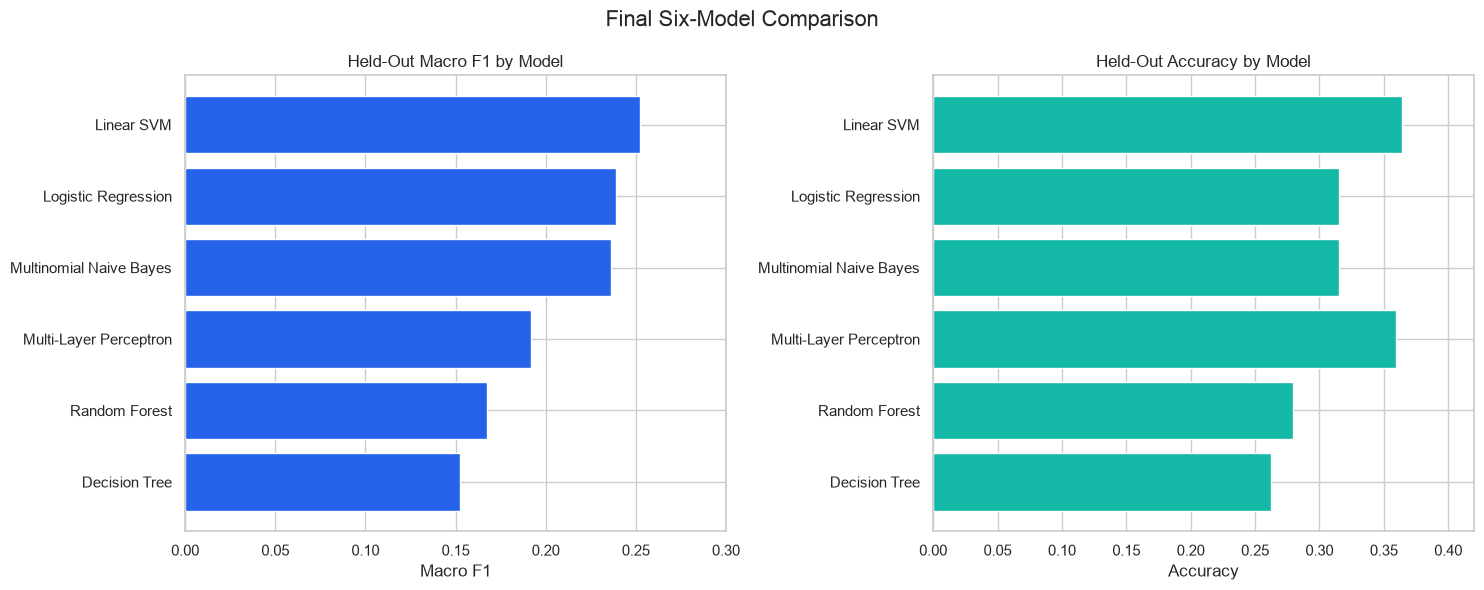

In [4]:
plot_df = comparison_df.sort_values("macro_f1")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(plot_df["model"], plot_df["macro_f1"], color="#2563eb")
axes[0].set_title("Held-Out Macro F1 by Model")
axes[0].set_xlabel("Macro F1")
axes[0].set_xlim(0, max(0.30, plot_df["macro_f1"].max() + 0.03))

axes[1].barh(plot_df["model"], plot_df["test_accuracy"], color="#14b8a6")
axes[1].set_title("Held-Out Accuracy by Model")
axes[1].set_xlabel("Accuracy")
axes[1].set_xlim(0, max(0.42, plot_df["test_accuracy"].max() + 0.03))

fig.suptitle("Final Six-Model Comparison", fontsize=16)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "final_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 5. Best-model selection

Macro F1 is the primary group metric because the target is severely imbalanced and every emotion class should contribute equally. The final held-out test set was not used during individual hyperparameter searches; it is used once here for the final model-family comparison.

Linear SVM is selected because it achieves the highest held-out macro F1 and highest held-out accuracy. Its remaining limitations—especially weak performance for `disgust`—must still be reported honestly.

In [5]:
best_row = comparison_df.iloc[0]

print("Selected model:", best_row["model"])
print("Student:", best_row["student_id"], best_row["student_name"])
print("Test macro F1:", round(best_row["macro_f1"], 4))
print("Test accuracy:", round(best_row["test_accuracy"], 4))
print("Weighted F1:", round(best_row["weighted_f1"], 4))
print("CV macro F1:", round(best_row["cv_macro_f1"], 4))

if best_row["model"] != "Linear SVM":
    raise ValueError(
        "The current genuine outputs no longer select Linear SVM. "
        "Review the updated comparison before continuing."
    )

selected_source = next(
    source
    for source in model_sources
    if source["model"] == best_row["model"]
)
selected_model_path = PROJECT_ROOT / selected_source["saved_model"]

with open(selected_model_path, "rb") as model_file:
    best_model = cloudpickle.load(model_file)

deployment_model_path = MODEL_DIR / "best_emotion_classifier.pkl"
with open(deployment_model_path, "wb") as model_file:
    cloudpickle.dump(best_model, model_file)

selection_summary = {
    "selected_model": best_row["model"],
    "student_id": best_row["student_id"],
    "selection_metric": "held_out_macro_f1",
    "test_macro_f1": float(best_row["macro_f1"]),
    "test_accuracy": float(best_row["test_accuracy"]),
    "weighted_f1": float(best_row["weighted_f1"]),
    "cv_macro_f1": float(best_row["cv_macro_f1"]),
    "source_model": str(selected_model_path.relative_to(PROJECT_ROOT)),
    "deployment_model": str(deployment_model_path.relative_to(PROJECT_ROOT)),
    "known_limitation": (
        "Minority-class performance, especially disgust, remains weak."
    ),
}

with open(
    OUTPUT_DIR / "best_model_selection.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(selection_summary, file, indent=2)

print("Saved selected model to:", deployment_model_path)

Selected model: Linear SVM
Student: IT25100083 Unawatuna H. M. I. D.
Test macro F1: 0.2523
Test accuracy: 0.3641
Weighted F1: 0.3661
CV macro F1: 0.2623


Saved selected model to: /Users/lakshithadilshan/Documents/movie-emotion-recommendation-system/models/best_emotion_classifier.pkl


## 6. Prepare the recommendation catalogue

For demonstration, the selected classifier predicts an emotion for every catalogue description. Recommendations are then filtered by predicted emotion, optional preferred genre, and minimum rating. Ranking combines normalized mean rating and log review popularity.

This is a content-based demonstration rather than a production collaborative-filtering system. The catalogue contains only movies represented in the assigned dataset.

In [6]:
FEATURES = [
    "Description",
    "genres_text",
    "mean_rating",
    "median_rating",
    "genre_count",
    "description_word_count",
    "description_character_count",
    "rating_range",
    "log_review_count",
    "log_unique_review_count",
]

catalogue = df.copy()
catalogue["predicted_emotion"] = best_model.predict(catalogue[FEATURES])

def minmax_series(series):
    minimum = series.min()
    maximum = series.max()
    if maximum == minimum:
        return pd.Series(0.0, index=series.index)
    return (series - minimum) / (maximum - minimum)

catalogue["rating_score"] = minmax_series(catalogue["mean_rating"])
catalogue["popularity_score"] = minmax_series(catalogue["log_review_count"])
catalogue["recommendation_score"] = (
    0.75 * catalogue["rating_score"]
    + 0.25 * catalogue["popularity_score"]
)

print("Catalogue descriptions:", len(catalogue))
display(
    catalogue["predicted_emotion"]
    .value_counts()
    .to_frame("predicted_count")
)

Catalogue descriptions: 2057


,predicted_count
predicted_emotion,
sadness,795
joy,360
anticipation,254
optimism,209
fear,188
anger,146
disgust,105


## 7. Emotion prediction and recommendation functions

In [7]:
def create_model_input(
    description,
    genres_text="unknown_genre",
    mean_rating=5.5,
    median_rating=None,
    review_count=1,
):
    description = str(description).strip()
    if not description:
        raise ValueError("Description must not be empty.")

    genres_text = str(genres_text).strip().lower() or "unknown_genre"
    genre_tokens = genres_text.split()
    median_rating = mean_rating if median_rating is None else median_rating
    review_count = max(int(review_count), 0)

    return pd.DataFrame([{
        "Description": description,
        "genres_text": genres_text,
        "mean_rating": float(mean_rating),
        "median_rating": float(median_rating),
        "genre_count": len(genre_tokens),
        "description_word_count": len(description.split()),
        "description_character_count": len(description),
        "rating_range": 0.0,
        "log_review_count": np.log1p(review_count),
        "log_unique_review_count": np.log1p(review_count),
    }])[FEATURES]


def predict_emotion(description, genres_text="unknown_genre"):
    model_input = create_model_input(
        description=description,
        genres_text=genres_text,
    )
    return str(best_model.predict(model_input)[0])


def recommend_movies(
    emotion,
    preferred_genre=None,
    minimum_rating=0.0,
    number_of_recommendations=10,
):
    emotion = str(emotion).strip().lower()
    candidates = catalogue[
        catalogue["predicted_emotion"].str.lower().eq(emotion)
        & catalogue["mean_rating"].ge(float(minimum_rating))
    ].copy()

    if preferred_genre:
        genre = str(preferred_genre).strip().lower().replace(" ", "_")
        genre_matches = candidates["genres_text"].str.split().apply(
            lambda values: genre in values
        )
        candidates = candidates[genre_matches].copy()

    candidates = (
        candidates.sort_values(
            ["recommendation_score", "mean_rating", "movie_name"],
            ascending=[False, False, True],
        )
        .drop_duplicates("movie_name")
        .head(int(number_of_recommendations))
    )

    return candidates[[
        "movie_name",
        "predicted_emotion",
        "genres_text",
        "mean_rating",
        "review_count",
        "recommendation_score",
    ]].reset_index(drop=True)


def emotion_aware_recommendation(
    description,
    preferred_genre=None,
    minimum_rating=0.0,
    number_of_recommendations=10,
):
    predicted_emotion = predict_emotion(
        description,
        genres_text=preferred_genre or "unknown_genre",
    )
    recommendations = recommend_movies(
        emotion=predicted_emotion,
        preferred_genre=preferred_genre,
        minimum_rating=minimum_rating,
        number_of_recommendations=number_of_recommendations,
    )
    return predicted_emotion, recommendations

## 8. Recommendation demonstration

The example supplies a new mood-oriented description, requests drama where available, and requires a mean rating of at least 6.0. The predicted emotion and ranked results are generated by executed code.

In [8]:
demo_description = (
    "A grieving musician returns home and slowly rebuilds hope "
    "through friendship, family, and a final performance."
)

predicted_emotion, recommendations = emotion_aware_recommendation(
    description=demo_description,
    preferred_genre="drama",
    minimum_rating=6.0,
    number_of_recommendations=10,
)

print("Input description:", demo_description)
print("Predicted emotion:", predicted_emotion)

if recommendations.empty:
    print(
        "No catalogue items met every filter. "
        "Running an emotion-only fallback."
    )
    recommendations = recommend_movies(
        emotion=predicted_emotion,
        minimum_rating=6.0,
        number_of_recommendations=10,
    )

display(recommendations.round({
    "mean_rating": 2,
    "recommendation_score": 4,
}))

recommendations.to_csv(
    OUTPUT_DIR / "recommendation_demo.csv",
    index=False,
)

Input description: A grieving musician returns home and slowly rebuilds hope through friendship, family, and a final performance.
Predicted emotion: sadness


,movie_name,predicted_emotion,genres_text,mean_rating,review_count,recommendation_score
0,The Promise,sadness,drama romance,9.59,88,0.8516
1,Titanic,sadness,drama romance thriller,9.67,18,0.8027
2,Brokeback Mountain,sadness,drama romance,9.53,17,0.7893
3,Moulin Rouge!,sadness,drama music romance,9.83,6,0.7809
4,Exit,sadness,drama mystery thriller,10.00,3,0.7748
5,Zero,sadness,drama,8.79,38,0.7553
6,Collateral Beauty,sadness,drama romance,8.80,20,0.7341
7,In the Land of Blood and Honey,sadness,drama romance war,8.67,24,0.7292
8,Vanilla Sky,sadness,drama mystery romance science_fiction thriller,8.73,15,0.7188
9,Les Misérables,sadness,crime drama history romance,8.10,60,0.7138


## 9. Final conclusion and limitations

**Selected model:** Linear SVM achieved the strongest held-out macro F1 and accuracy among the six assigned models. Linear text classifiers generalized better than the tree-based dense-SVD models on this limited, high-dimensional dataset.

**Recommendation demonstration:** The selected classifier predicts the emotion of a supplied description. Catalogue candidates are filtered using that predicted emotion, optional genre preference, and minimum rating, then ranked using rating and review popularity.

**Limitations:**

- Overall macro F1 remains modest, so predictions must not be presented as certain.
- `Disgust` performance is especially weak because only 73 independent examples exist.
- The catalogue contains assigned-dataset movies rather than a live movie database.
- Recommendation ranking does not use personal viewing history or collaborative filtering.
- Genre combinations are represented as text tokens, and new metadata uses sensible defaults.
- `Surprise` cannot be predicted because its three records were insufficient for supervised training.

**Future improvements:**

- Collect more independently labelled minority-class descriptions.
- Evaluate contextual embeddings or transformer models.
- Calibrate confidence scores and support abstention for uncertain predictions.
- Add user profiles, feedback, diversity controls, and collaborative signals.
- Evaluate recommendation relevance with real users.

## AI tool usage declaration

Generative AI assistance was used for code structuring, debugging suggestions, documentation organization, and explanation refinement. Every output in this notebook must be generated by executed code and verified by the group.